# Adding things together: Code
------------------------------------------------------------------------------------------------------------------
*Start: 13-05-2026, Latest change: 13-05-2026*

Based on the preliminaries of data exploration and data comprehension as well as a personally setup workflow done in other notebooks, this page should be the entire workflow put together.

All required packages for this code can be found in the *enviroment.yml* file.

------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------
### *Contents*
1. Introduction: Code preliminaries
2. Data Description: data checks, filtering out unreliable data
3. Exploratory Data Analysis: distribution, range of data, descriptive statistics with histograms, temporal patterns, spatial patterns
4. Comparative Sensor Analyis
5. Spatial Analysis
6. Interactive Visualization

------------------------------------------------------------------------------------------------------------------
## 1. Introduction
Import required libraries, access data: request and load data based on specific subvariables we are interested in. Convert datatypes, dataformat to a more useful GeoPandas DataFrame that allows for advanced analysis and visualization.  

To change:
- Add automatic checks with if loops to the current code!

In [2]:
# i.1.0 Importing libraries
import requests
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO

# i.1.1) Specify API URL and make a request
## specify different subvariables of API 
MAP_KEY = "c1637686346099a509207bbf06a29650"

DATA = "VIIRS_SNPP_NRT" # selecting product
AREA = "world"
DAY_RANGE = 1 
DATE = "2026-05-10"  # YYYY-MM-DD, if empty = most recent data

## building URL based on those subvariables (makes it more specific)
api_url = f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{MAP_KEY}/{DATA}/{AREA}/{DAY_RANGE}/{DATE}"

# i.1.2 Requesting data
response = requests.get(api_url)

# i.1.3 Check whether request worked by checking status code and print first few lines
if response.status_code == 200:
    print("Request successful!")
    print(response.text[:202]) # successful if column headers are visible

Request successful!
latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
51.90226,51.37084,309.96,0.74,0.76,2026-05-10,28,N,VIIRS,n,2.0NRT,272.09,2.29,N


In [4]:
# i.2.1 convert data from CSV format to a pandas dataframe
df = pd.read_csv(StringIO(response.text))

# convert datatypes
# convert acq_date and acq_time to TimeStamps, merge date and time together
df["acq_date"] = pd.to_datetime(df["acq_date"])
df["acq_time"] = df["acq_time"].astype(str).str.zfill(4)

df["datetime"] = pd.to_datetime(
    df["acq_date"].astype(str) + " " + df["acq_time"],
    format="%Y-%m-%d %H%M")

# check datatypes to see whether the conversion worked
display(df.dtypes)

df.head()

latitude             float64
longitude            float64
bright_ti4           float64
scan                 float64
track                float64
acq_date      datetime64[ns]
acq_time              object
satellite             object
instrument            object
confidence            object
version               object
bright_ti5           float64
frp                  float64
daynight              object
datetime      datetime64[ns]
dtype: object

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,datetime
0,51.90226,51.37084,309.96,0.74,0.76,2026-05-10,0028,N,VIIRS,n,2.0NRT,272.09,2.29,N,2026-05-10 00:28:00
1,52.01697,51.14882,298.72,0.72,0.76,2026-05-10,0028,N,VIIRS,n,2.0NRT,269.72,1.00,N,2026-05-10 00:28:00
2,52.73573,50.18405,295.04,0.63,0.72,2026-05-10,0028,N,VIIRS,n,2.0NRT,271.90,0.51,N,2026-05-10 00:28:00
3,52.80345,52.15229,306.85,0.72,0.76,2026-05-10,0028,N,VIIRS,n,2.0NRT,274.39,3.00,N,2026-05-10 00:28:00
4,52.87273,51.22464,314.02,0.67,0.74,2026-05-10,0028,N,VIIRS,n,2.0NRT,272.23,2.46,N,2026-05-10 00:28:00


In [6]:
# i.2.4 convert to a geopandas object and visualize 
fire_gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326")

# create useful temporal columns (ideal for plotting and temporal analysis later)
fire_gdf["year"] = fire_gdf["datetime"].dt.year
fire_gdf["month"] = fire_gdf["datetime"].dt.month
fire_gdf["day"] = fire_gdf["datetime"].dt.day
fire_gdf["hour"] = fire_gdf["datetime"].dt.hour
fire_gdf["weekday"] = fire_gdf["datetime"].dt.day_name()

fire_gdf.head()

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,...,bright_ti5,frp,daynight,datetime,geometry,year,month,day,hour,weekday
0,51.90226,51.37084,309.96,0.74,0.76,2026-05-10,0028,N,VIIRS,n,...,272.09,2.29,N,2026-05-10 00:28:00,POINT (51.37084 51.90226),2026,5,10,0,Sunday
1,52.01697,51.14882,298.72,0.72,0.76,2026-05-10,0028,N,VIIRS,n,...,269.72,1.00,N,2026-05-10 00:28:00,POINT (51.14882 52.01697),2026,5,10,0,Sunday
2,52.73573,50.18405,295.04,0.63,0.72,2026-05-10,0028,N,VIIRS,n,...,271.90,0.51,N,2026-05-10 00:28:00,POINT (50.18405 52.73573),2026,5,10,0,Sunday
3,52.80345,52.15229,306.85,0.72,0.76,2026-05-10,0028,N,VIIRS,n,...,274.39,3.00,N,2026-05-10 00:28:00,POINT (52.15229 52.80345),2026,5,10,0,Sunday
4,52.87273,51.22464,314.02,0.67,0.74,2026-05-10,0028,N,VIIRS,n,...,272.23,2.46,N,2026-05-10 00:28:00,POINT (51.22464 52.87273),2026,5,10,0,Sunday


------------------------------------------------------------------------------------------------------------------
## 2. Data Description
Checking data: value range, columns, NaNs, filtering out unreliable data  
Starting with basic questions = how many detections, missing values, value ranges

In [7]:
display(fire_gdf.head())

print(fire_gdf.columns)

print(fire_gdf.info())

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,...,bright_ti5,frp,daynight,datetime,geometry,year,month,day,hour,weekday
0,51.90226,51.37084,309.96,0.74,0.76,2026-05-10,0028,N,VIIRS,n,...,272.09,2.29,N,2026-05-10 00:28:00,POINT (51.37084 51.90226),2026,5,10,0,Sunday
1,52.01697,51.14882,298.72,0.72,0.76,2026-05-10,0028,N,VIIRS,n,...,269.72,1.00,N,2026-05-10 00:28:00,POINT (51.14882 52.01697),2026,5,10,0,Sunday
2,52.73573,50.18405,295.04,0.63,0.72,2026-05-10,0028,N,VIIRS,n,...,271.90,0.51,N,2026-05-10 00:28:00,POINT (50.18405 52.73573),2026,5,10,0,Sunday
3,52.80345,52.15229,306.85,0.72,0.76,2026-05-10,0028,N,VIIRS,n,...,274.39,3.00,N,2026-05-10 00:28:00,POINT (52.15229 52.80345),2026,5,10,0,Sunday
4,52.87273,51.22464,314.02,0.67,0.74,2026-05-10,0028,N,VIIRS,n,...,272.23,2.46,N,2026-05-10 00:28:00,POINT (51.22464 52.87273),2026,5,10,0,Sunday


Index(['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date',
       'acq_time', 'satellite', 'instrument', 'confidence', 'version',
       'bright_ti5', 'frp', 'daynight', 'datetime', 'geometry', 'year',
       'month', 'day', 'hour', 'weekday'],
      dtype='object')
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 27064 entries, 0 to 27063
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   latitude    27064 non-null  float64       
 1   longitude   27064 non-null  float64       
 2   bright_ti4  27064 non-null  float64       
 3   scan        27064 non-null  float64       
 4   track       27064 non-null  float64       
 5   acq_date    27064 non-null  datetime64[ns]
 6   acq_time    27064 non-null  object        
 7   satellite   27064 non-null  object        
 8   instrument  27064 non-null  object        
 9   confidence  27064 non-null  object        
 10  version     27064 n

**Next Step:** Initial filtering of unreliable data = low confidence, missing values

In [8]:
# inspect confidence column first
display(fire_gdf["confidence"].value_counts()) # n = nominal, l = low, h = high


# check for NaN values
df.isna().sum() # 0 NaN values,  !!!!! maybe include an automatic check (if NaNs do a filtering/drop na)

# filter all low values
gdf_filtered = fire_gdf[fire_gdf["confidence"] != "l"]
gdf_filtered["confidence"].value_counts() # now only h and n values are included

confidence
n    23142
l     2659
h     1263
Name: count, dtype: int64

confidence
n    23142
h     1263
Name: count, dtype: int64

------------------------------------------------------------------------------------------------------------------

## 3. Exploratory Data Analysis
statistics: histogram to explore distributions, data ranges, etc.

Temporal unterstanding = detections per day, per hour, do those values differ day vs. night
-> use bar plots

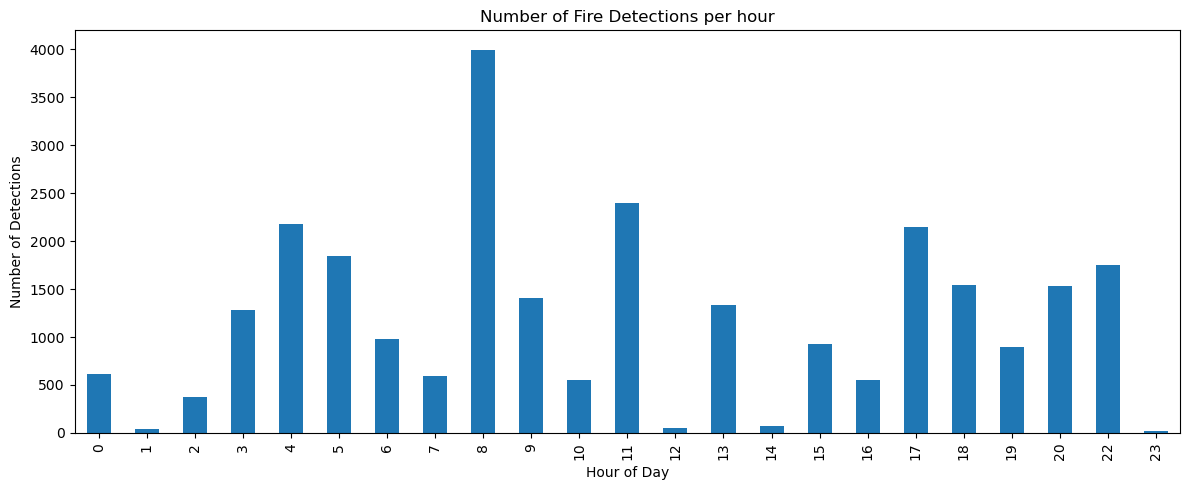

In [11]:
hourly_counts = fire_gdf.groupby("hour").size()

plt.figure(figsize=(12,5))
daily_counts.plot(kind="bar")

plt.title("Number of Fire Detections per hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Detections")

plt.tight_layout()
plt.show()

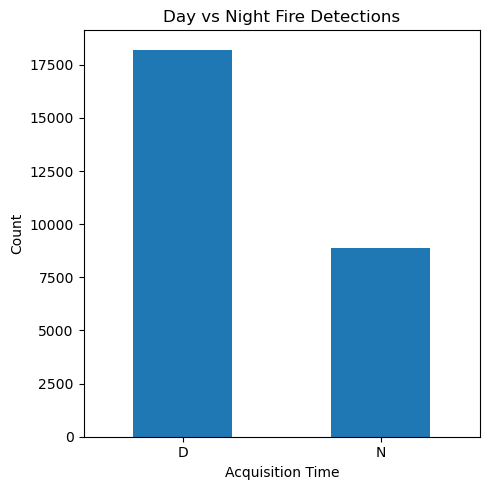

In [12]:
daynight_counts = fire_gdf["daynight"].value_counts()

plt.figure(figsize=(5,5))
daynight_counts.plot(kind="bar")

plt.title("Day vs Night Fire Detections")
plt.xlabel("Acquisition Time")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Check Attribute values distributions (frp, confidence, brightness, scan size ?)

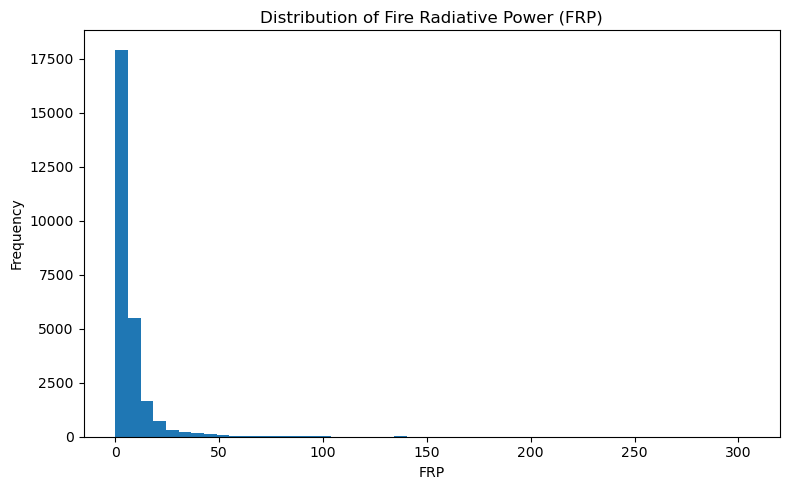

In [13]:
plt.figure(figsize=(8,5))

plt.hist(fire_gdf["frp"], bins=50)

plt.title("Distribution of Fire Radiative Power (FRP)")
plt.xlabel("FRP")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

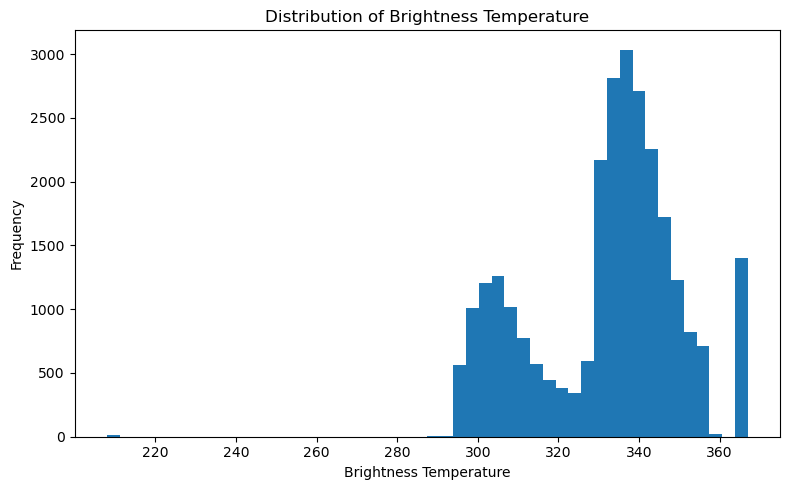

In [15]:
plt.figure(figsize=(8,5))

plt.hist(fire_gdf["bright_ti4"], bins=50)

plt.title("Distribution of Brightness Temperature")
plt.xlabel("Brightness Temperature")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

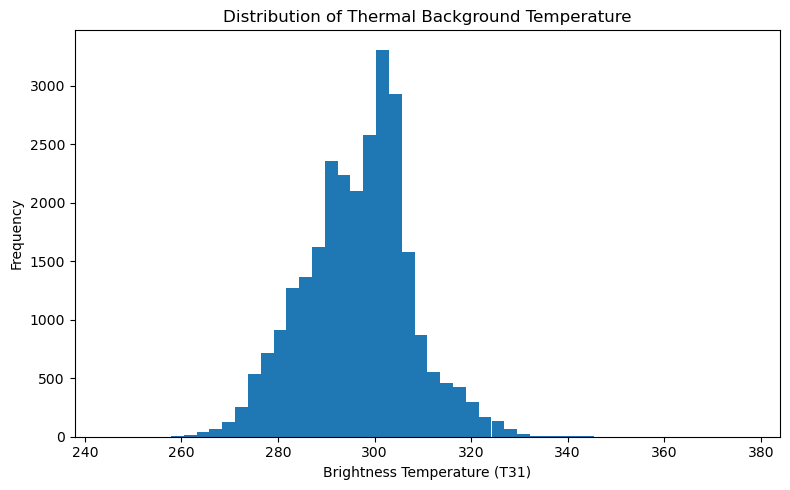

In [18]:
plt.figure(figsize=(8,5))

plt.hist(fire_gdf["bright_ti5"], bins=50)

plt.title("Distribution of Thermal Background Temperature")
plt.xlabel("Brightness Temperature (T31)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

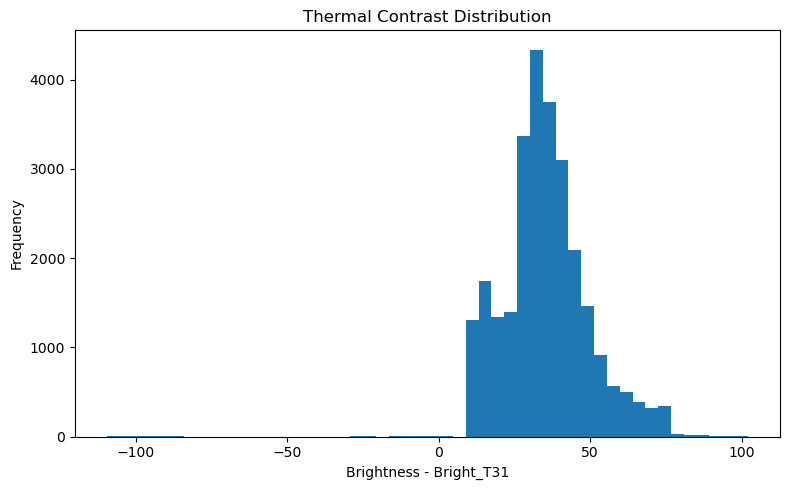

In [19]:
fire_gdf["temp_diff"] = (
    fire_gdf["bright_ti4"] -
    fire_gdf["bright_ti5"]
)

plt.figure(figsize=(8,5))

plt.hist(fire_gdf["temp_diff"], bins=50)

plt.title("Thermal Contrast Distribution")
plt.xlabel("Brightness - Bright_T31")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [22]:
fire_gdf[
    ["frp", "bright_ti4", "bright_ti5", "scan"]
].describe()

,frp,bright_ti4,bright_ti5,scan
count,27064.000000,27064.000000,27064.000000,27064.000000
mean,7.514596,331.970842,296.604868,0.472847
std,13.501086,18.365881,11.110026,0.090335
min,0.080000,208.000000,244.550000,0.320000
25%,2.040000,318.537500,289.450000,0.400000
50%,4.200000,335.570000,297.550000,0.450000
75%,7.840000,343.400000,303.630000,0.530000
max,304.770000,367.000000,377.340000,0.800000


------------------------------------------------------------------------------------------------------------------

## 4. Comparative Sensor Analysis
....

------------------------------------------------------------------------------------------------------------------

## 5. Spatial Analysis
...

------------------------------------------------------------------------------------------------------------------

## 6. Interactive Visualization
...